
=== DATA QUALITY SUMMARY ===
Duplicate timestamps : 50
Missing timestamps   : 25
Zero values          : 103
NaN values           : 2
Negative values      : 0

================ DETAILED LISTS ================

--- Duplicate Timestamps (Showing first 10) ---
      Date  Time  Total Load (MW)
2024-09-15 23:00            40.76
2024-09-15 23:00            40.76
2025-05-26 00:00            36.98
2025-05-26 01:00            36.71
2025-05-26 02:00            39.03
2025-05-26 03:00            39.74
2025-05-26 04:00            42.01
2025-05-26 05:00            41.39
2025-05-26 06:00            49.14
2025-05-26 07:00            53.52

--- Missing Timestamps (Showing first 10) ---
2024-09-14 23:00
2025-05-27 00:00
2025-05-27 01:00
2025-05-27 02:00
2025-05-27 03:00
2025-05-27 04:00
2025-05-27 05:00
2025-05-27 06:00
2025-05-27 07:00
2025-05-27 08:00

--- Zero Values (Showing first 10) ---
      Date  Time  Total Load (MW)
2025-08-09 06:00              0.0
2025-08-09 07:00              0.0
2025-08-0

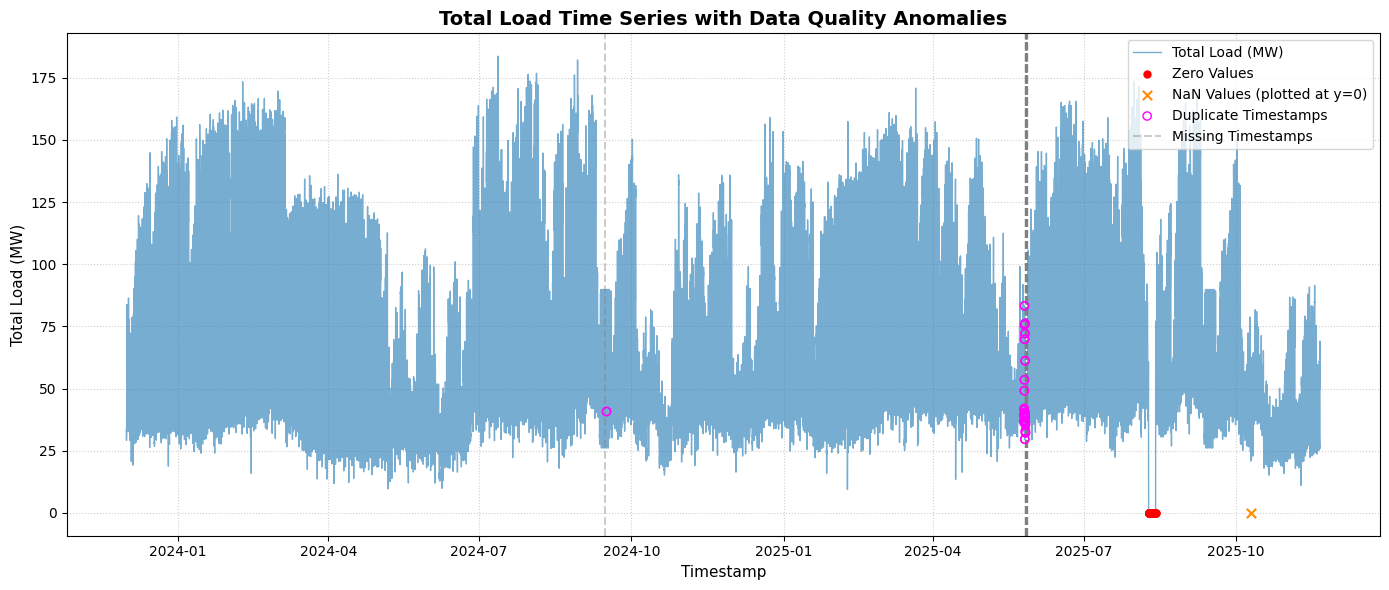

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD & CLEAN THE DATASET
# ==========================================
# Load the CSV file
df = pd.read_csv("Hourly_Data_220kV.csv")

# Combine Date and Time strings into a unified datetime object
df["Timestamp"] = pd.to_datetime(df["Date"] + " " + df["Time"])
load_col = "Total Load (MW)"

# Fix the string/object issue: force everything to numbers.
# Anything that can't convert (spaces, characters) automatically becomes NaN.
df[load_col] = pd.to_numeric(df[load_col], errors="coerce")


# ==========================================
# 2. IDENTIFY ANOMALIES & ISSUES
# ==========================================
# Duplicate timestamps: keep=False flags all instances so you see both rows
duplicates = df[df.duplicated(subset=["Timestamp"], keep=False)]

# Missing timestamps: Compare actual data against an unbroken hourly timeline
ideal_range = pd.date_range(
    start=df["Timestamp"].min(), end=df["Timestamp"].max(), freq="h"
)
missing = ideal_range.difference(df["Timestamp"])

# Value-based data quality issues
zero_vals = df[df[load_col] == 0]
nan_vals = df[df[load_col].isna()]
negative_vals = df[df[load_col] < 0]


# ==========================================
# 3. PRINT DATA QUALITY SUMMARY
# ==========================================
print("\n=== DATA QUALITY SUMMARY ===")
print(f"Duplicate timestamps : {len(duplicates)}")
print(f"Missing timestamps   : {len(missing)}")
print(f"Zero values          : {len(zero_vals)}")
print(f"NaN values           : {len(nan_vals)}")
print(f"Negative values      : {len(negative_vals)}")


# ==========================================
# 4. DETAILED BREAKDOWN LISTS
# ==========================================
print("\n================ DETAILED LISTS ================")

if len(duplicates) > 0:
    print(f"\n--- Duplicate Timestamps (Showing first 10) ---")
    print(duplicates[["Date", "Time", load_col]].head(10).to_string(index=False))

if len(missing) > 0:
    print(f"\n--- Missing Timestamps (Showing first 10) ---")
    print(pd.Series(missing).dt.strftime('%Y-%m-%d %H:%M').head(10).to_string(index=False))

if len(zero_vals) > 0:
    print(f"\n--- Zero Values (Showing first 10) ---")
    print(zero_vals[["Date", "Time", load_col]].head(10).to_string(index=False))

if len(nan_vals) > 0:
    print(f"\n--- NaN / Invalid Values (Showing first 10) ---")
    print(nan_vals[["Date", "Time", load_col]].head(10).to_string(index=False))

if len(negative_vals) > 0:
    print(f"\n--- Negative Values (Showing first 10) ---")
    print(negative_vals[["Date", "Time", load_col]].head(10).to_string(index=False))


# ==========================================
# 5. TIME-SERIES VISUALIZATION
# ==========================================
print("\n================ GENERATING PLOT ================")

# Sort chronologically so the line plot doesn't crisscross jaggedly
df_sorted = df.sort_values("Timestamp")

fig, ax = plt.subplots(figsize=(14, 6))

# Plot the primary load curve trend
ax.plot(
    df_sorted["Timestamp"],
    df_sorted[load_col],
    label="Total Load (MW)",
    color="#1f77b4",
    alpha=0.6,
    linewidth=1
)

# Highlight zero entries as bright red dots
if len(zero_vals) > 0:
    ax.scatter(
        zero_vals["Timestamp"],
        zero_vals[load_col],
        color="red",
        label="Zero Values",
        zorder=5,
        s=25
    )

# Highlight negative entries as purple dots
if len(negative_vals) > 0:
    ax.scatter(
        negative_vals["Timestamp"],
        negative_vals[load_col],
        color="purple",
        label="Negative Values",
        zorder=5,
        s=25
    )

# Highlight NaN dropouts as orange 'X' markers along the baseline axis
if len(nan_vals) > 0:
    ax.scatter(
        nan_vals["Timestamp"],
        [0] * len(nan_vals),
        color="darkorange",
        marker="x",
        label="NaN Values (plotted at y=0)",
        zorder=5,
        s=45
    )

# Highlight duplicated entries with a hollow magenta ring
if len(duplicates) > 0:
    ax.scatter(
        duplicates["Timestamp"],
        duplicates[load_col],
        color="magenta",
        marker="o",
        facecolors="none",
        edgecolors="magenta",
        label="Duplicate Timestamps",
        zorder=4,
        s=35
    )

# Drop vertical dashed lines to spotlight data timeline gaps (missing hours)
if len(missing) > 0:
    for i, m_time in enumerate(missing):
        if i == 0:
            ax.axvline(m_time, color="gray", linestyle="--", alpha=0.4, label="Missing Timestamps")
        else:
            ax.axvline(m_time, color="gray", linestyle="--", alpha=0.4)

# Aesthetics and formatting
ax.set_title("Total Load Time Series with Data Quality Anomalies", fontsize=14, fontweight="bold")
ax.set_xlabel("Timestamp", fontsize=11)
ax.set_ylabel("Total Load (MW)", fontsize=11)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()

# Save the final file to your current working directory
plt.savefig("load_data_quality_plot.png", dpi=300)
print("Done! The visual plot has been saved as 'load_data_quality_plot.png'.")